# **Fine-tuning a Pruned ResNet18 for CIFAR10**


Pangilinan, Reignel Bernice A.

2018-01460

## **Build the dataset and dataloader**

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, models
from tqdm import tqdm
import matplotlib.pyplot as plt

# Load the CIFAR10 dataset
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

text_labels = train_dataset.classes

# Create dataloaders
batch_size_train = 1024
batch_size_test = 512

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size_train, shuffle=True, num_workers=2)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size_test, shuffle=False, num_workers=2)

print(f"\nTrain dataloader created with batchsize: {batch_size_train}")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Each sample in the training set has the size: {train_dataset[0][0].shape}")
print(f"\nTest dataloader created with batchsize: {batch_size_test}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Each sample in the test set has the size: {test_dataset[0][0].shape}")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")


Train dataloader created with batchsize: 1024
Number of training samples: 50000
Each sample in the training set has the size: torch.Size([3, 32, 32])

Test dataloader created with batchsize: 512
Number of test samples: 10000
Each sample in the test set has the size: torch.Size([3, 32, 32])

Using device: cuda


## **Visualize samples from the dataset**

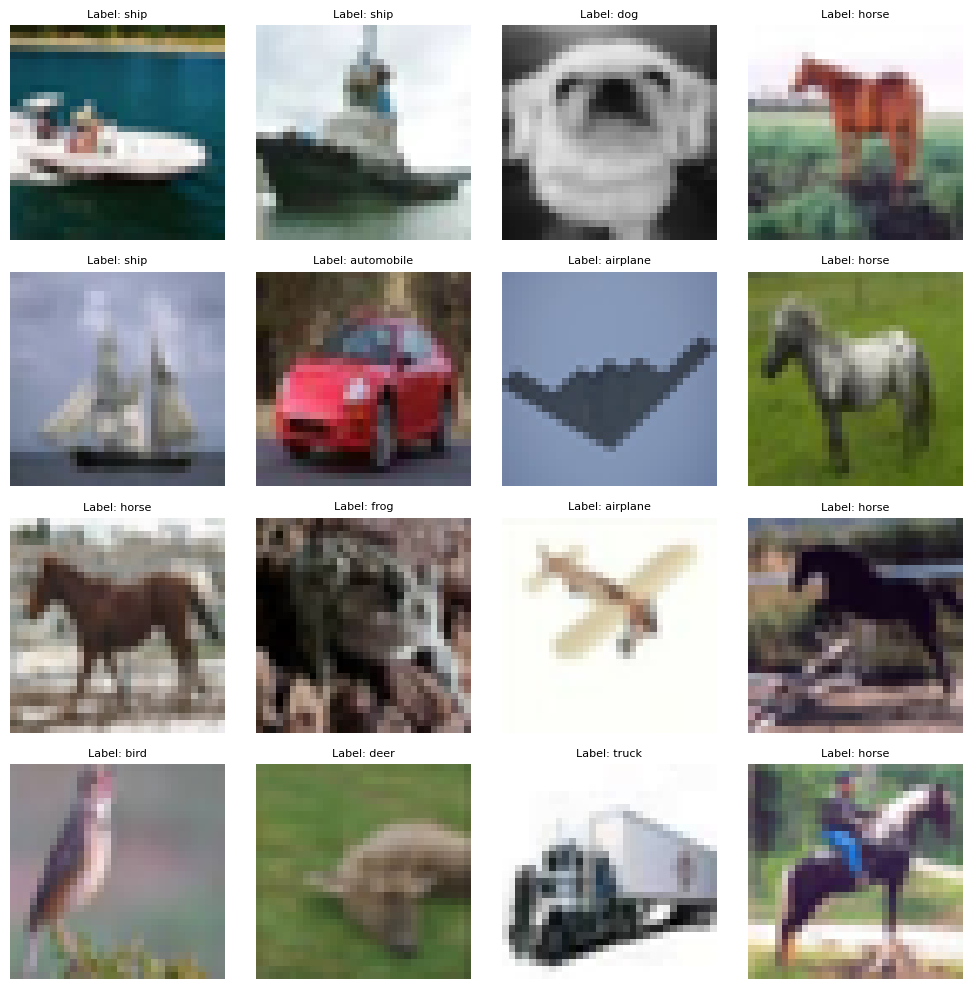

In [ ]:
import numpy as np

# Get 16 random indices
indices = np.random.choice(len(train_dataset), size = 16, replace = False)

# Get the corresponding images and labels
images = [train_dataset[i][0] for i in indices]
labels = [train_dataset[i][1] for i in indices]

# Create a figure with 4x4 subplots
fig, axes = plt.subplots(4, 4, figsize = (10, 10))

for i, ax in enumerate(axes.flat):
    # Get the image tensor (guaranteed to be a torch.Tensor as per user)
    img = images[i]

    # Transpose the image from (channel, height, width) to (height, width, channel)
    # and convert to a NumPy array for displaying with matplotlib
    img_np = img.numpy().transpose((1, 2, 0))

    # The images are normalized, un-normalize for display
    # mean = np.array([0.485, 0.456, 0.406])
    # std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * 0.5 + 0.5  # Unnormalize
    img_np = np.clip(img_np, 0, 1) # Clip to valid range [0, 1]


    ax.imshow(img_np)
    ax.set_title(f"Label: {text_labels[labels[i]]}", fontsize = 8)   # Display the label
    ax.axis("off")

# Adjust the spacing between subplots
plt.tight_layout()

# Show the figure
plt.show()

## **Prune and Fine-tune the ResNet18 model**

In this context, the **head** pertains to the `fc` or classifier layer with the `Linear(in_features=512, out_features=10, bias=True)` in the ResNet18 model modified for the CIFAR10 dataset. The **tail**, on the other hand, pertains to the feature extractor `(conv) → (bn) → (relu)` in the `BasicBlock()` of the ResNet18 model.

In [ ]:
def ResNet18_for_CIFAR10():
    model = models.resnet18(weights="ResNet18_Weights.DEFAULT")
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1,
                            padding=1, bias=False)  # CIFAR-10 adaptation
    model.maxpool = nn.Identity()  # Remove maxpool
    return model.to(device)

def FreezeBackbone(model):
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True
    return model

# Training and evaluation functions
def Train(model, loader, criterion, optimizer, epochs, silent=False):
    model.train()
    for epoch in range(epochs):
        for inputs, labels in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()
        if not silent:
            print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

def Evaluate(model, test_dataloader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Features for modifying the pruned ResNet18 model to the CIFAR10 dataset
def GetFeatureDim(model, device="cuda"):
    model.eval()
    x = torch.randn(1, 3, 32, 32).to(device)
    with torch.no_grad():
        x = model.conv1(x)
        x = model.bn1(x)
        x = model.relu(x)
        if not isinstance(model.layer1, nn.Identity):
            x = model.layer1(x)
        if not isinstance(model.layer2, nn.Identity):
            x = model.layer2(x)
        if not isinstance(model.layer3, nn.Identity):
            x = model.layer3(x)
        if not isinstance(model.layer4, nn.Identity):
            x = model.layer4(x)
        x = model.avgpool(x)
        x = torch.flatten(x, 1)
    return x.shape[1]

def AdaptFC(model, num_classes=10, device="cuda"):
    in_features = GetFeatureDim(model, device)
    model.fc = nn.Linear(in_features, num_classes).to(device)
    return FreezeBackbone(model)  # always freeze after replacing FC


# Function for pruning blocks or layers in the pre-trained ResNet18 model
def PruneBlock(model, block_name):
    names = block_name.split(".")
    target = model
    for n in names[:-1]:
        target = getattr(target, n)
    last_name = names[-1]
    if last_name.isdigit():
        target[int(last_name)] = nn.Identity()
    else:
        setattr(model, last_name, nn.Identity())

### **Pretrained ResNet18 model**

In [ ]:
# Display the original ResNet18 model
original_model = ResNet18_for_CIFAR10()
print(original_model.named_modules)

<bound method Module.named_modules of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64

### **Pruning by block**

In [ ]:
lr = 0.001
momentum = 0.9
epochs = 10
criterion = nn.CrossEntropyLoss()

# Baseline
model = ResNet18_for_CIFAR10()
model = AdaptFC(model, num_classes=10, device=device)

print("\nTraining baseline model (only FC)...")
optimizer = optim.SGD(model.fc.parameters(), lr=lr, momentum=momentum)
Train(model, train_dataloader, criterion, optimizer, epochs=epochs, silent=True)
baseline_acc = Evaluate(model, test_dataloader)
print(f"Baseline accuracy: {baseline_acc:.2f}%")

accuracies = [baseline_acc]


Training baseline model (only FC)...


Epoch 10/10: 100%|██████████| 49/49 [00:14<00:00,  3.27it/s]


Baseline accuracy: 47.07%


In [ ]:
# Prune progressively by block
pruning_blocks = [
    "layer4.1", "layer4.0",
    "layer3.1", "layer3.0",
    "layer2.1", "layer2.0",
    "layer1.1", "layer1.0",
]

for block in pruning_blocks:
    PruneBlock(model, block)
    model = AdaptFC(model, num_classes=10, device=device)

    print(f"\nFine-tuning after pruning {block}...")
    optimizer = optim.SGD(model.fc.parameters(), lr=lr, momentum=momentum)
    Train(model, train_dataloader, criterion, optimizer, epochs=epochs, silent=True)

    acc = Evaluate(model, test_dataloader)
    accuracies.append(acc)
    print(f"Accuracy after pruning {block}: {acc:.2f}%")


Fine-tuning after pruning layer4.1...


Epoch 10/10: 100%|██████████| 49/49 [00:13<00:00,  3.73it/s]


Accuracy after pruning layer4.1: 29.66%

Fine-tuning after pruning layer4.0...


Epoch 10/10: 100%|██████████| 49/49 [00:13<00:00,  3.76it/s]


Accuracy after pruning layer4.0: 25.60%

Fine-tuning after pruning layer3.1...


...

Accuracy after pruning layer2.0: 18.03%

Fine-tuning after pruning layer1.1...


Epoch 10/10: 100%|██████████| 49/49 [00:11<00:00,  4.15it/s]


Accuracy after pruning layer1.1: 19.80%

Fine-tuning after pruning layer1.0...


Epoch 10/10: 100%|██████████| 49/49 [00:11<00:00,  4.18it/s]


Accuracy after pruning layer1.0: 18.42%


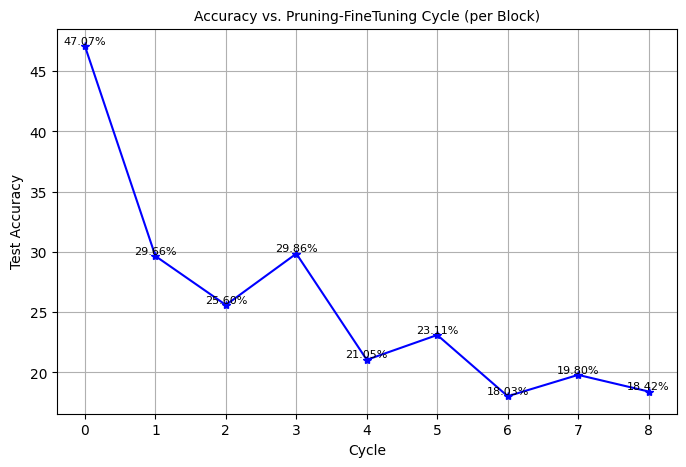

In [ ]:
# Plot results
plt.figure(figsize=(8, 5))
plt.plot(accuracies, marker="*", color="b")
plt.xlabel("Cycle", fontsize=10)
plt.ylabel("Test Accuracy", fontsize=10)
plt.title("Accuracy vs. Pruning-FineTuning Cycle (per Block)", fontsize=10)
plt.grid(True)
for i, acc in enumerate(accuracies):
    plt.text(i, acc, f"{acc:.2f}%", ha="center", va="bottom", fontsize=8)
plt.show()

Cycle 0 in the plot above refers to the baseline model without pruning. Based on the accuracy vs. pruning-fine-tuning plot above, the performance of the pruned ResNet18 model for the CIFAR10 dataset appear to significantly deviate and degrade from the baseline as blocks `layer2.1` up until `layer1.0` are pruned. Note that the baseline accuracy is not that good in the first place since we are using a pre-trained ResNet18 model on the CIFAR10 dataset. Nonetheless, we see that structured depth pruning does have a significant effect on the performance of the model.  

In [ ]:
### Display the model details after pruning
print(model.named_modules)

<bound method Module.named_modules of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Identity()
    (1): Identity()
  )
  (layer2): Sequential(
    (0): Identity()
    (1): Identity()
  )
  (layer3): Sequential(
    (0): Identity()
    (1): Identity()
  )
  (layer4): Sequential(
    (0): Identity()
    (1): Identity()
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_features=64, out_features=10, bias=True)
)>


### **Pruning by layer**

In [ ]:
# Prune by layer
model1 = ResNet18_for_CIFAR10()
model1 = AdaptFC(model1, num_classes=10, device=device)

accuracies1 = [baseline_acc]
pruning_layers = ["layer4", "layer3", "layer2", "layer1"]

for layer in pruning_layers:
    PruneBlock(model1, layer)
    model1 = AdaptFC(model1, num_classes=10, device=device)

    print(f"\nFine-tuning after pruning {layer}...")
    optimizer = optim.SGD(model1.fc.parameters(), lr=lr, momentum=momentum)
    Train(model1, train_dataloader, criterion, optimizer, epochs=epochs, silent=True)

    acc = Evaluate(model1, test_dataloader)
    accuracies1.append(acc)
    print(f"Accuracy after pruning {layer}: {acc:.2f}%")


Fine-tuning after pruning layer4...


Epoch 10/10: 100%|██████████| 49/49 [00:13<00:00,  3.75it/s]


Accuracy after pruning layer4: 25.08%

Fine-tuning after pruning layer3...


Epoch 10/10: 100%|██████████| 49/49 [00:12<00:00,  3.91it/s]


Accuracy after pruning layer3: 25.17%

Fine-tuning after pruning layer2...


Epoch 10/10: 100%|██████████| 49/49 [00:11<00:00,  4.11it/s]


Accuracy after pruning layer2: 21.94%

Fine-tuning after pruning layer1...


Epoch 10/10: 100%|██████████| 49/49 [00:11<00:00,  4.18it/s]


Accuracy after pruning layer1: 19.17%


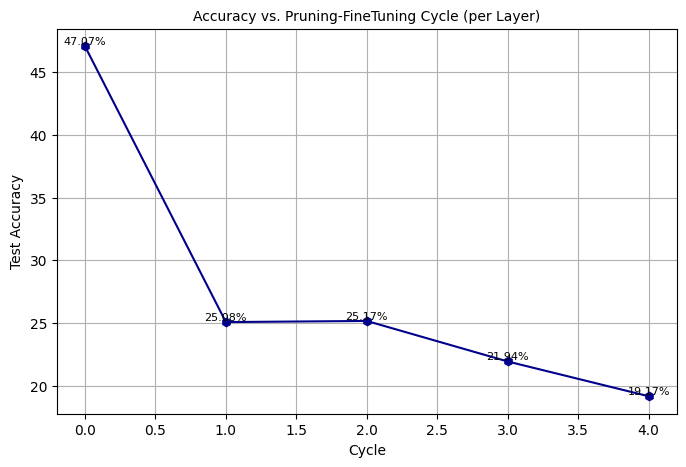

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(accuracies1, marker="h", color="darkblue")
plt.xlabel("Cycle", fontsize=10)
plt.ylabel("Test Accuracy", fontsize=10)
plt.title("Accuracy vs. Pruning-FineTuning Cycle (per Layer)", fontsize=10)
plt.grid(True)
for i, acc in enumerate(accuracies1):
    plt.text(i, acc, f"{acc:.2f}%", ha="center", va="bottom", fontsize=8)
plt.show()

Cycle 0 in the plot above refers to the baseline model without pruning. When performing pruning by layer, we see that the model performance degrades after pruning 2 layers as compared to the baseline accuracy. This result is somewhat similar to that of the per-block pruning approach. This tells us that the ResNet18 model needs atleast **2 layers** containing the `BasicBlock()` to somewhat keep the model from degrading drastically as compared to the baseline model without pruning.

In [ ]:
### Display the model after pruning
print(model1.named_modules)

<bound method Module.named_modules of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Identity()
  (layer2): Identity()
  (layer3): Identity()
  (layer4): Identity()
  (avgpool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_features=64, out_features=10, bias=True)
)>
